# Reading GRIN2B line NWB Files

This notebook demonstrates how to read the converted GRIN2B NWB files from the Gonzalez-Sulser Lab. It covers:

1. Loading the NWB file and inspecting top-level metadata
2. Reading raw EEG/EMG acquisition data
3. Full-recording EEG spectrogram
4. Reading sleep-state epoch annotations
5. Sleep states by hour
6. Reading per-sleep-state power spectra
7. Reading seizure event intervals
8. EEG/EMG around a seizure event
9. Reading per-epoch spike-wave discharge (SWD) counts

**Prerequisites:** `pynwb`, `matplotlib`, `numpy`, `pandas`

```bash
conda activate gonzalez-sulser-lab-to-nwb-env
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

# Update this path to the location of your NWB file.
NWB_PATH = Path(
    # "H:/gonzalez-nwbfiles/nwb_stub/sub-GRIN2B-129/sub-GRIN2B-129_ses-2021-03-26_ecephys.nwb"
    "H:/gonzalez-nwbfiles/sub-GRIN2B-129/sub-GRIN2B-129_ses-2021-03-26_ecephys.nwb"
)

## 1. Load and inspect top-level metadata

In [2]:
io = NWBHDF5IO(NWB_PATH, mode="r")
nwb = io.read()
nwb.experiment_description

'Chronic wireless EEG and EMG recordings from freely behaving Long-Evans rats carrying a heterozygous knockout of Grin2b (Grin2b+/-), the gene encoding the GluN2B subunit of N-methyl-D-aspartate receptors (NMDARs). Grin2b+/- rats display spontaneous spike-and-wave discharges (SWDs, the electrographic correlate of absence seizures) at higher incidence and duration than wild-type littermates, alongside reduced REM sleep and altered NREM/wake distributions. Recordings were acquired over 72-96 h using the TaiNi wireless multichannel recording system (Tainitec, UK) with 14-channel skull-surface EEG electrode grids and bilateral neck EMG electrodes, at 250.4 Hz. Two consecutive 24-h baseline windows (BL1, BL2) were extracted per animal. Automated pipelines classified sleep states (Wake, NREM, REM) in 5-s epochs and detected SWD seizure events. Data contribute to the SFARI Autism Rat Models Consortium (ARC). See Hristova et al., Epilepsia 2025 (doi:10.1111/epi.18606).\n'

In [3]:
print(f"Session ID:          {nwb.session_id}")
print(f"Session start time:  {nwb.session_start_time}")
print(f"Institution:         {nwb.institution}")
print(f"Lab:                 {nwb.lab}")
print(f"Subject ID:          {nwb.subject.subject_id}")
print(f"Subject species:     {nwb.subject.species}")
print()
print("Acquisition keys:", list(nwb.acquisition.keys()))
print("Processing modules:", list(nwb.processing.keys()))

epochs_df = nwb.epochs.to_dataframe()
print()
print(
    "Baseline windows 1 and 2 are marked in the NWB epochs table (seconds relative to session_start_time)"
)
epochs_df[:]
bl1_start_time = epochs_df["start_time"][0]
bl2_start_time = epochs_df["start_time"][1]

Session ID:          2021-03-26
Session start time:  2021-03-26 10:55:59.996006+00:00
Institution:         University of Edinburgh
Lab:                 Gonzalez-Sulser Lab
Subject ID:          GRIN2B-129
Subject species:     Rattus norvegicus

Acquisition keys: ['EEGElectricalSeries', 'EMGElectricalSeries']
Processing modules: ['behavior', 'ecephys']

Baseline windows 1 and 2 are marked in the NWB epochs table (seconds relative to session_start_time)


## 2. Raw EEG / EMG

The full 24 h recording is stored as **two** `ElectricalSeries` in `acquisition` - one for
EEG, one for EMG - sharing a single electrode table but linked to distinct `ElectrodeGroup`s:

- `EEGElectricalSeries{baseline_name}`: **14 EEG channels** - bilateral cortex - S1_Tr, M2_Fra, M2_anterior, M1_anterior, V2_ML, V1_M, S1Hl_S1Fl (Right + Left)
- `EMGElectricalSeries{baseline_name}`: **2 EMG channels** - Right and Left


In [4]:
eeg_name = next(name for name in nwb.acquisition if name.startswith("EEGElectricalSeries"))
emg_name = next(name for name in nwb.acquisition if name.startswith("EMGElectricalSeries"))
eeg_es = nwb.acquisition[eeg_name]
emg_es = nwb.acquisition[emg_name]

for name, es in [("EEG", eeg_es), ("EMG", emg_es)]:
    print(f"--- {name} ---")
    print(f"ElectricalSeries shape:  {es.data.shape}")
    print(f"Sampling rate:           {es.rate} Hz")
    print(
        f"Starting time:           {es.starting_time:.2f} s (= session_start_time; full recording)"
    )
    print(f"Duration:                {es.data.shape[0] / es.rate / 3600:.2f} h")
    print(f"Conversion (to volts):   {es.conversion:.6e}")
    print()

electrodes = nwb.electrodes.to_dataframe()
electrodes[:]

--- EEG ---
ElectricalSeries shape:  (69391534, 14)
Sampling rate:           250.4 Hz
Starting time:           0.00 s (= session_start_time; full recording)
Duration:                76.98 h
Conversion (to volts):   3.173828e-06

--- EMG ---
ElectricalSeries shape:  (69391534, 2)
Sampling rate:           250.4 Hz
Starting time:           0.00 s (= session_start_time; full recording)
Duration:                76.98 h
Conversion (to volts):   3.173828e-06



,location,group,group_name,channel_name,filtering,rel_y,hemisphere,rel_x
id,,,,,,,,
0,S1_Tr,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,S1_Tr_R,none,2.8,R,-3.0
1,M2_Fra,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,M2_Fra_R,none,1.2,R,3.6
2,M2_anterior,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,M2_anterior_R,none,1.2,R,1.5
3,M1_anterior,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,M1_anterior_R,none,2.8,R,1.5
4,V2_ML,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,V2_ML_R,none,3.0,R,-5.0
5,V1_M,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,V1_M_R,none,3.0,R,-7.0
6,S1Hl_S1Fl,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,S1Hl_S1Fl_R,none,2.8,R,-1.0
7,V1_M,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,V1_M_L,none,3.0,L,-7.0
8,V2_ML,EEGArray pynwb.ecephys.ElectrodeGroup at 0x230...,EEGArray,V2_ML_L,none,3.0,L,-5.0


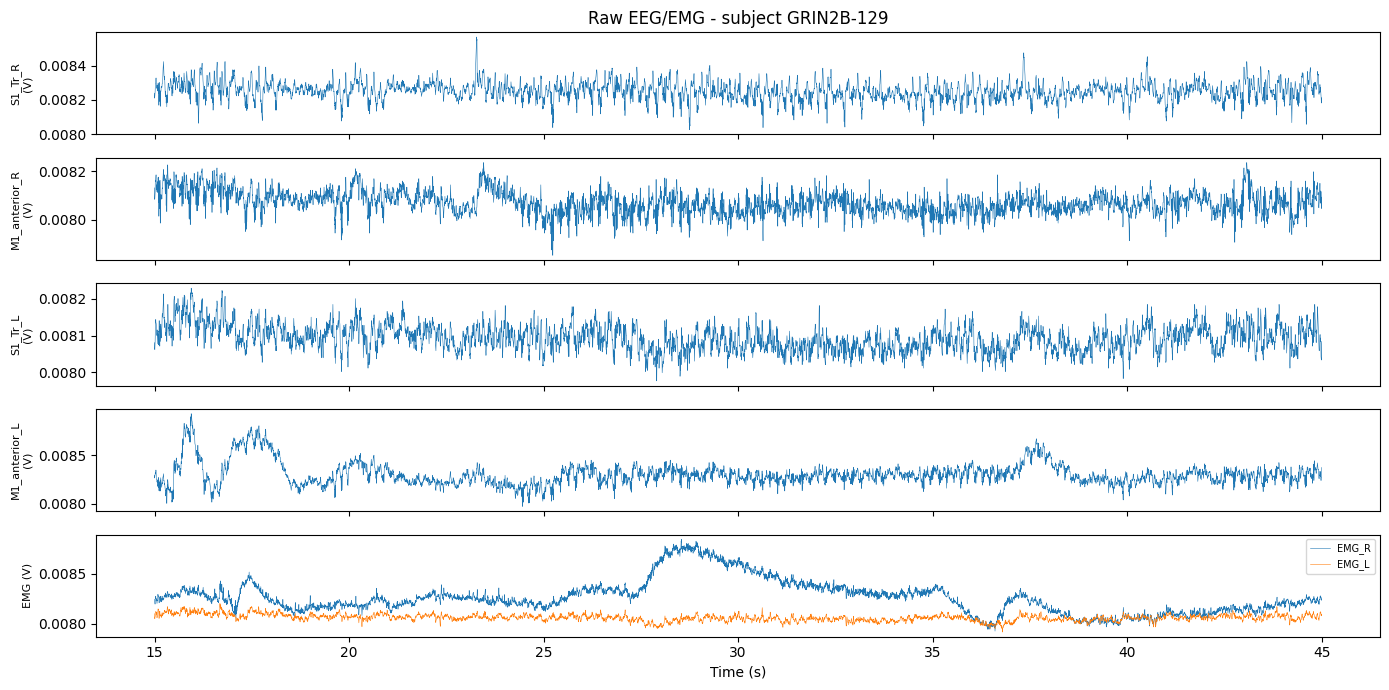

In [5]:
fs = eeg_es.rate
window_start_s = 15
window_duration_s = 30
window_end_s = window_start_s + window_duration_s

i_start = int(window_start_s * fs)
i_end = int(window_end_s * fs)

# Convert raw int16 ADC counts to volts using the confirmed TainiTec gain
# (es.conversion is in volts/count). The full recording is indexed directly
eeg_slice = eeg_es.data[i_start:i_end, :] * eeg_es.conversion  # lazy HDF5 read
emg_slice = emg_es.data[i_start:i_end, :] * emg_es.conversion  # lazy HDF5 read

t = eeg_es.get_timestamps()[i_start:i_end]

# EEG channels: indices within EEGElectricalSeries (14 channels) — pick a bilateral pair
eeg_idx = {"S1_Tr_R": 0, "M1_anterior_R": 3, "S1_Tr_L": 13, "M1_anterior_L": 10}
# EMG channels: indices within EMGElectricalSeries (2 channels)
emg_idx = {"EMG_R": 0, "EMG_L": 1}

fig, axes = plt.subplots(len(eeg_idx) + 1, 1, figsize=(14, 7), sharex=True)

for ax, (label, idx) in zip(axes[:-1], eeg_idx.items()):
    ax.plot(t, eeg_slice[:, idx], lw=0.4)
    ax.set_ylabel(f"{label}\n(V)", fontsize=8)

ax_emg = axes[-1]
for label, idx in emg_idx.items():
    ax_emg.plot(t, emg_slice[:, idx], lw=0.4, label=label)
ax_emg.set_ylabel("EMG (V)", fontsize=8)
ax_emg.legend(fontsize=7, loc="upper right")
ax_emg.set_xlabel(f"Time (s)")

axes[0].set_title(f"Raw EEG/EMG - subject {nwb.subject.subject_id}")
plt.tight_layout()
plt.show()

## 3. EEG spectrogram

Reproduces the lab's per-epoch spectrogram plot (`spec_129_BL2.png`): raw EEG power is
computed in the same 5-s epochs as the sleep scoring, then split into fixed-duration
panels stacked top-to-bottom to cover the full recording.

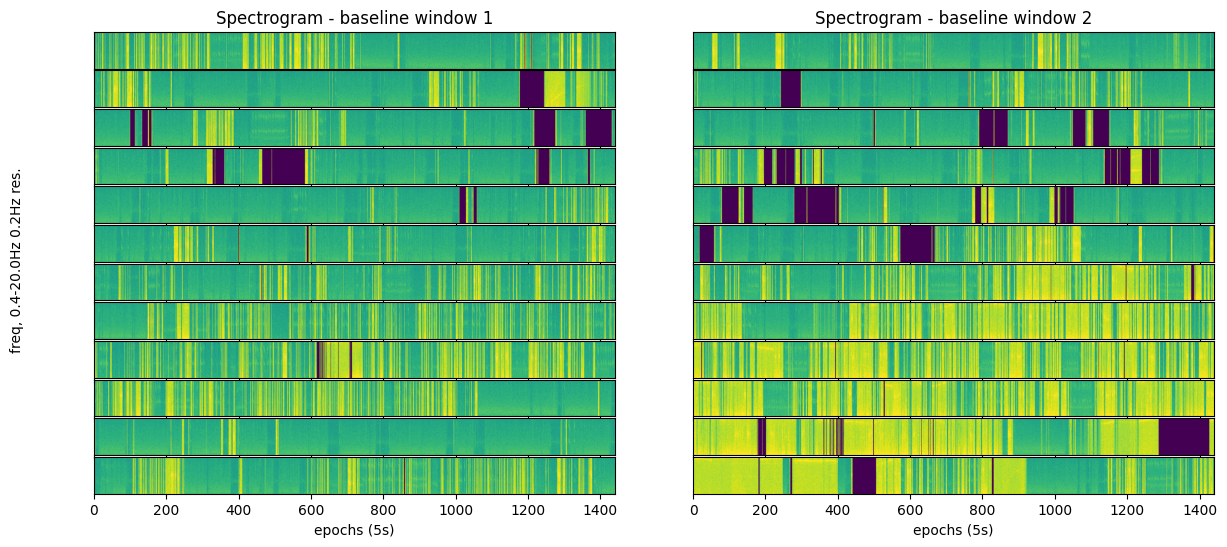

In [60]:
# ── Spectrogram parameters ────────────────────────────────────────────────────
channel_idx = 0  # EEG channel to use (index into eeg_es channels)
freq_min, freq_max = 0.4, 20.0  # Hz - matches the lab's plotting band
panel_duration_h = 2.0  # hours of recording per stacked panel
# ──────────────────────────────────────────────────────────────────────────────

fs = eeg_es.rate
epoch_len_s = 5.0  # same epoch length as the sleep scoring (Section 4)
n_per_epoch = int(round(epoch_len_s * fs))

baseline_windows = [
    ("baseline window 1", bl1_start_time, epochs_df["stop_time"][0]),
    ("baseline window 2", bl2_start_time, epochs_df["stop_time"][1]),
]

freqs = np.fft.rfftfreq(n_per_epoch, d=1 / fs)
freq_mask = (freqs >= freq_min) & (freqs <= freq_max)
freqs = freqs[freq_mask]

log_powers = []
for label, start_s, stop_s in baseline_windows:
    i_start = int(start_s * fs)
    i_stop = int(stop_s * fs)
    n_epochs = (i_stop - i_start) // n_per_epoch

    eeg_channel = eeg_es.data[
        i_start : i_start + n_epochs * n_per_epoch, channel_idx
    ]* eeg_es.conversion
    epochs = eeg_channel.reshape(n_epochs, n_per_epoch)

    power = np.abs(np.fft.rfft(epochs, axis=1)) ** 2
    log_power = np.log10(power[:, freq_mask] + np.finfo(float).eps)
    log_powers.append((label, log_power))

epochs_per_panel = int(panel_duration_h * 3600 / epoch_len_s)
n_panels = max(
    int(np.ceil(log_power.shape[0] / epochs_per_panel)) for _, log_power in log_powers
)
vmin, vmax = np.percentile(
    np.concatenate([lp for _, lp in log_powers], axis=0), [1, 99]
)

fig, axes = plt.subplots(
    n_panels, 2, figsize=(14, 0.5 * n_panels), sharex=True, squeeze=False
)
for col, (label, log_power) in enumerate(log_powers):
    n_epochs = log_power.shape[0]
    for panel in range(n_panels):
        ax = axes[panel, col]
        i0 = panel * epochs_per_panel
        i1 = min(i0 + epochs_per_panel, n_epochs)
        if i0 >= n_epochs:
            ax.axis("off")
            continue
        ax.imshow(
            log_power[i0:i1].T,
            aspect="auto",
            origin="lower",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            extent=[0, i1 - i0, freq_min, freq_max],
        )
        ax.set_yticks([])
    axes[0, col].set_title(f"Spectrogram - {label}")
    axes[-1, col].set_xlabel("epochs (5s)")

fig.text(
    0.04,
    0.5,
    f"freq, {freq_min}-{freq_max}Hz 0.2Hz res.",
    va="center",
    rotation="vertical",
)
plt.subplots_adjust(hspace=0.05, wspace=0.15, left=0.1)
plt.show()

## 4. Sleep-state epochs

5-second scored epochs are stored in a single merged table,
`processing/behavior/sleep_states`, spanning all baseline windows. A
`baseline_window` column (matching the tags in `nwb.epochs`) identifies which
baseline window each row belongs to.
State codes: 0 = Wake, 1 = NREM, 2 = REM. State 4 = SWD

In [7]:
behavior = nwb.processing["behavior"]
sleep_df = behavior["sleep_states"].to_dataframe()
sleep_df_bl1 = sleep_df[sleep_df["baseline_window"] == "baseline_window_1"]
sleep_df_bl2 = sleep_df[sleep_df["baseline_window"] == "baseline_window_2"]

In [8]:
print(
    f"Sleep epochs in the baseline window 1: {len(sleep_df_bl1)} rows (expected 17,280 for full 24 h)"
)
sleep_df_bl1[:]

Sleep epochs in the baseline window 1: 17280 rows (expected 17,280 for full 24 h)


,start_time,stop_time,sleep_score,sleep_state,baseline_window
id,,,,,
0,72240.003994,72245.003994,0,Wake,baseline_window_1
1,72245.003994,72250.003994,0,Wake,baseline_window_1
2,72250.003994,72255.003994,0,Wake,baseline_window_1
3,72255.003994,72260.003994,0,Wake,baseline_window_1
4,72260.003994,72265.003994,0,Wake,baseline_window_1
...,...,...,...,...,...
17275,158615.003994,158620.003994,1,NREM,baseline_window_1
17276,158620.003994,158625.003994,1,NREM,baseline_window_1
17277,158625.003994,158630.003994,1,NREM,baseline_window_1


In [9]:
print(
    f"Sleep epochs in the baseline window 2: {len(sleep_df_bl2)} rows (expected 17,280 for full 24 h)"
)
sleep_df_bl2[:]

Sleep epochs in the baseline window 2: 17280 rows (expected 17,280 for full 24 h)


,start_time,stop_time,sleep_score,sleep_state,baseline_window
id,,,,,
17280,158640.003994,158645.003994,1,NREM,baseline_window_2
17281,158645.003994,158650.003994,1,NREM,baseline_window_2
17282,158650.003994,158655.003994,1,NREM,baseline_window_2
17283,158655.003994,158660.003994,1,NREM,baseline_window_2
17284,158660.003994,158665.003994,1,NREM,baseline_window_2
...,...,...,...,...,...
34555,245015.003994,245020.003994,0,Wake,baseline_window_2
34556,245020.003994,245025.003994,0,Wake,baseline_window_2
34557,245025.003994,245030.003994,0,Wake,baseline_window_2


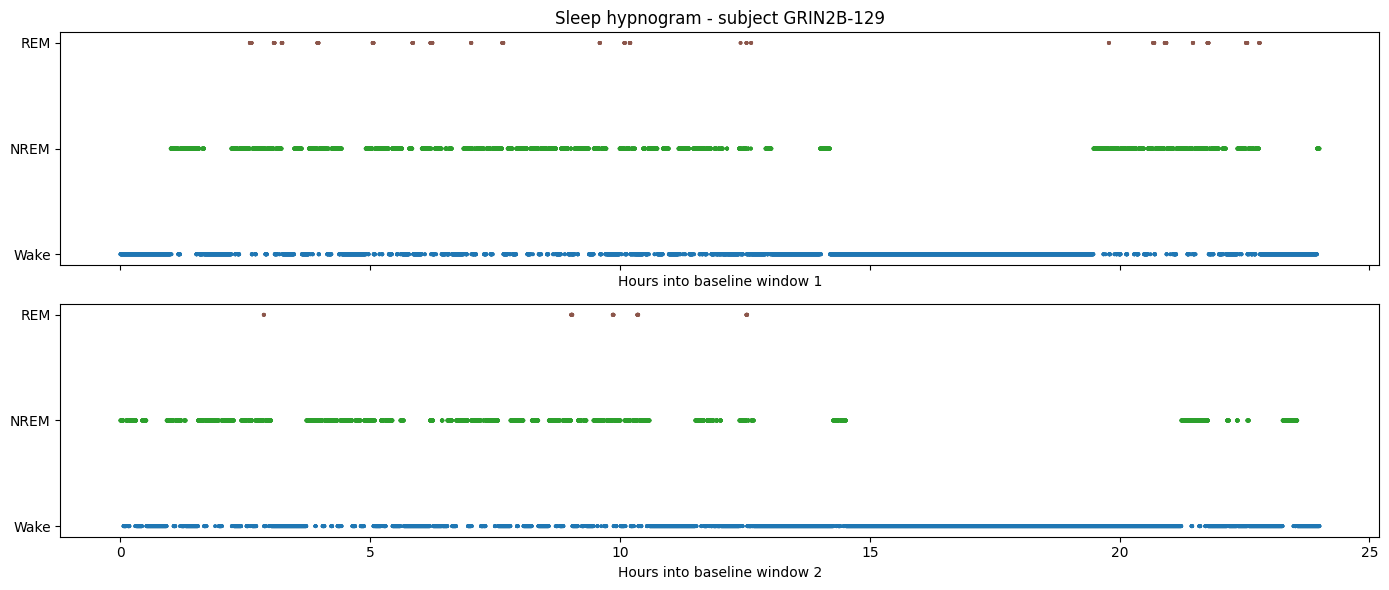

In [10]:
# Sleep hypnogram
state_labels = {0: "Wake", 1: "NREM", 2: "REM", 4: "SWD"}
t_mid = (sleep_df_bl1["start_time"] + sleep_df_bl1["stop_time"]) / 2
hours = (t_mid - bl1_start_time) / 3600  # hours into BL1 window

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].scatter(
    hours,
    sleep_df_bl1["sleep_score"],
    s=3,
    c=sleep_df_bl1["sleep_score"],
    cmap="tab10",
    vmin=0,
    vmax=4,
)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Wake", "NREM", "REM"])
axes[0].set_xlabel("Hours into baseline window 1")
axes[1].scatter(
    hours,
    sleep_df_bl2["sleep_score"],
    s=3,
    c=sleep_df_bl2["sleep_score"],
    cmap="tab10",
    vmin=0,
    vmax=4,
)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["Wake", "NREM", "REM"])
axes[1].set_xlabel("Hours into baseline window 2")
axes[0].set_title(f"Sleep hypnogram - subject {nwb.subject.subject_id}")
plt.tight_layout()
plt.show()

## 5. Sleep states by hour

Stacked bar chart of epoch counts per hour since lights-on, reproducing the lab's
`States by Hour` plot (e.g. `sbh_129_BL1.png`).

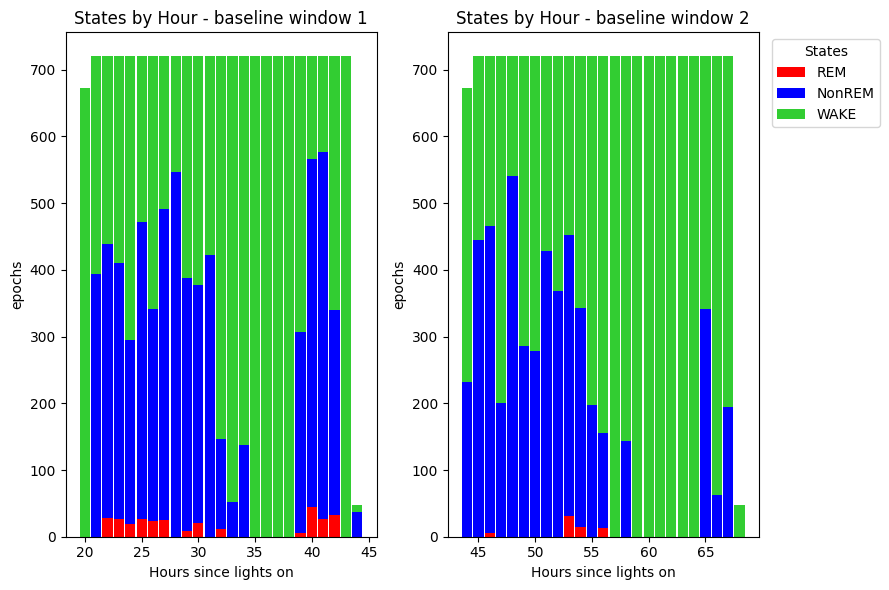

In [11]:
state_names = {0: "WAKE", 1: "NonREM", 2: "REM"}

# Bin each 5-s epoch into the hour (since lights-on / BL window start) it falls in
hours_since_lights_on_bl1 = np.floor(
    (sleep_df_bl1["start_time"] - eeg_es.starting_time) / 3600
).astype(int)

counts_by_hour_bl1 = (
    sleep_df_bl1["sleep_score"]
    .map(state_names)
    .groupby(hours_since_lights_on_bl1)
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["REM", "NonREM", "WAKE"], fill_value=0)
    .sort_index()
)

hours_since_lights_on_bl2 = np.floor(
    (sleep_df_bl2["start_time"] - eeg_es.starting_time) / 3600
).astype(int)

counts_by_hour_bl2 = (
    sleep_df_bl2["sleep_score"]
    .map(state_names)
    .groupby(hours_since_lights_on_bl2)
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["REM", "NonREM", "WAKE"], fill_value=0)
    .sort_index()
)

fig, axes = plt.subplots(1,2, figsize=(9, 6))
bottom = np.zeros(len(counts_by_hour_bl1))
colors = {"WAKE": "limegreen", "NonREM": "blue", "REM": "red"}
for state in ["REM", "NonREM", "WAKE"]:
    axes[0].bar(
        counts_by_hour_bl1.index,
        counts_by_hour_bl1[state],
        bottom=bottom,
        width=0.9,
        color=colors[state],
        label=state,
    )
    bottom += counts_by_hour_bl1[state].to_numpy()

axes[0].set_xlabel("Hours since lights on")
axes[0].set_ylabel("epochs")
axes[0].set_title("States by Hour - baseline window 1")

bottom = np.zeros(len(counts_by_hour_bl2))
colors = {"WAKE": "limegreen", "NonREM": "blue", "REM": "red"}
for state in ["REM", "NonREM", "WAKE"]:
    axes[1].bar(
        counts_by_hour_bl2.index,
        counts_by_hour_bl2[state],
        bottom=bottom,
        width=0.9,
        color=colors[state],
        label=state,
    )
    bottom += counts_by_hour_bl2[state].to_numpy()

axes[1].set_xlabel("Hours since lights on")
axes[1].set_ylabel("epochs")
axes[1].set_title("States by Hour - baseline window 2")
axes[1].legend(title="States", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. Per-sleep-state power spectra

628 frequency bins per baseline window (0→125.2 Hz, 0.2 Hz steps = Nyquist of 250.4 Hz),
stored in a single table, `processing/ecephys/sleep_state_power_spectra`. Columns
are named after the brain state: `Wake`, `NREM`, `REM`, `SWD`; a `baseline_window` column
identifies which baseline window each row belongs to.

In [12]:
ecephys = nwb.processing["ecephys"]
psd_df = ecephys["sleep_state_power_spectra"].to_dataframe()
psd_df_bl1 = psd_df[psd_df["baseline_window"] == "baseline_window_1"]
psd_df_bl2 = psd_df[psd_df["baseline_window"] == "baseline_window_2"]

In [13]:
print(f"PSD table: {psd_df_bl1.shape}")
psd_df_bl1[:]

PSD table: (627, 6)


,frequency_hz,Wake,NREM,REM,SWD,baseline_window
id,,,,,,
0,0.0,0.519809,0.539314,0.123515,0.634967,baseline_window_1
1,0.2,0.497687,0.535483,0.108808,0.614226,baseline_window_1
2,0.4,0.483442,0.558114,0.093001,0.598746,baseline_window_1
3,0.6,0.453522,0.574946,0.070813,0.554426,baseline_window_1
4,0.8,0.439977,0.590124,0.068346,0.537512,baseline_window_1
...,...,...,...,...,...,...
622,124.4,0.042762,0.004024,0.005191,0.070005,baseline_window_1
623,124.6,0.042678,0.004111,0.005180,0.070263,baseline_window_1
624,124.8,0.042597,0.004328,0.005418,0.070568,baseline_window_1


In [14]:
print(f"PSD table: {psd_df_bl2.shape}")
psd_df_bl2[:]

PSD table: (627, 6)


,frequency_hz,Wake,NREM,REM,SWD,baseline_window
id,,,,,,
627,0.0,0.864452,0.935737,0.533670,1.050656,baseline_window_2
628,0.2,0.875762,0.965950,0.550871,1.060105,baseline_window_2
629,0.4,0.907634,1.033543,0.585353,1.090748,baseline_window_2
630,0.6,1.020505,1.194127,0.702763,1.190375,baseline_window_2
631,0.8,1.070288,1.274803,0.764896,1.238579,baseline_window_2
...,...,...,...,...,...,...
1249,124.4,0.046641,0.006989,0.006511,0.096875,baseline_window_2
1250,124.6,0.046434,0.007045,0.006427,0.096319,baseline_window_2
1251,124.8,0.046176,0.007037,0.006313,0.095381,baseline_window_2


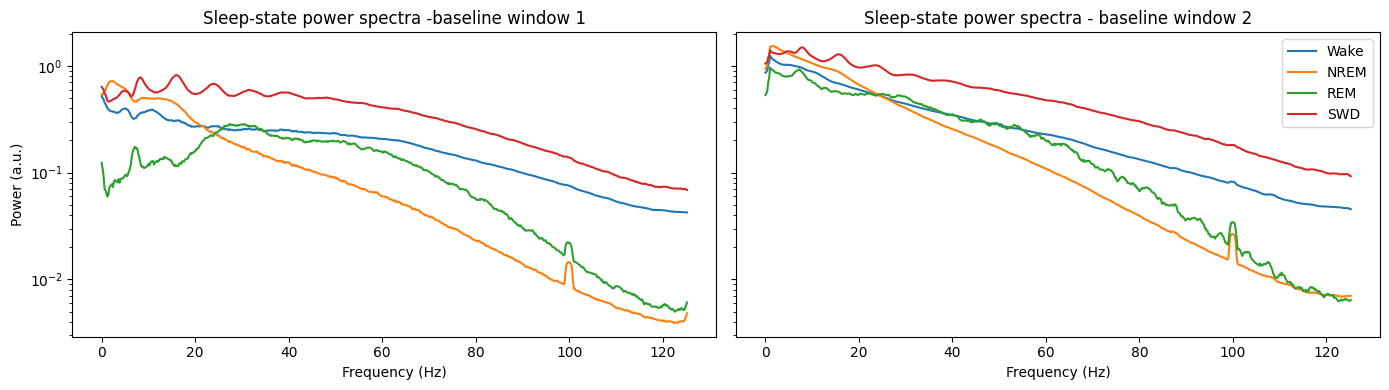

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
state_cols = ["Wake", "NREM", "REM", "SWD"]
for col in state_cols:
    if col in psd_df_bl1.columns:
        axes[0].semilogy(psd_df_bl1["frequency_hz"], psd_df_bl1[col], label=col)
# ax.set_xlim(0, 50)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power (a.u.)")
axes[0].set_title("Sleep-state power spectra -baseline window 1")
# axes[0].legend()
for col in state_cols:
    if col in psd_df_bl2.columns:
        axes[1].semilogy(psd_df_bl2["frequency_hz"], psd_df_bl2[col], label=col)
# ax.set_xlim(0, 50)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Sleep-state power spectra - baseline window 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Seizure events

Stored as a `pynwb.epoch.TimeIntervals` table in
`processing/behavior/seizure_events`, spanning all baseline windows. The table has one
row per seizure event, with `start_time`, `stop_time`, `duration`, and `baseline_window`
columns - split on `baseline_window` to recover the BL1/BL2 subsets used below.

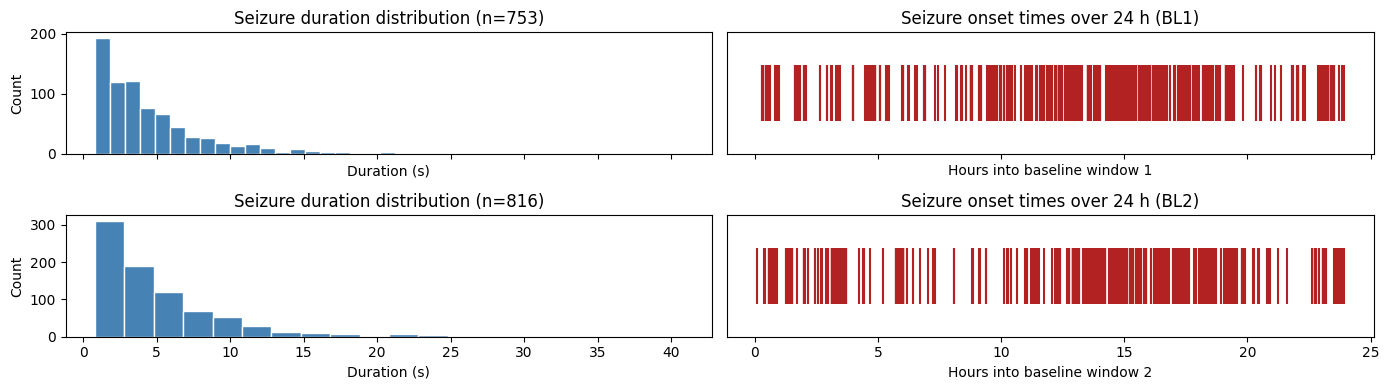

In [20]:
seizure_df = behavior["seizure_events"].to_dataframe()
seizure_df_bl1 = seizure_df[seizure_df["baseline_window"] == "baseline_window_1"]

start_times_bl1 = seizure_df_bl1["start_time"].to_numpy()
stop_times_bl1 = seizure_df_bl1["stop_time"].to_numpy()
durations_bl1 = seizure_df_bl1["duration"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 4), sharex="col")

# Duration histogram
axes[0][0].hist(durations_bl1, bins=20, color="steelblue", edgecolor="white")
axes[0][0].set_xlabel("Duration (s)")
axes[0][0].set_ylabel("Count")
axes[0][0].set_title(f"Seizure duration distribution (n={len(durations_bl1)})")

# Event timeline relative to BL1 window start
rel_start_bl1 = (start_times_bl1 - bl1_start_time) / 3600
axes[0][1].eventplot(rel_start_bl1, lineoffsets=0, linelengths=0.5, color="firebrick")
axes[0][1].set_xlabel("Hours into baseline window 1")
axes[0][1].set_yticks([])
axes[0][1].set_title("Seizure onset times over 24 h (BL1)")

seizure_df_bl2 = seizure_df[seizure_df["baseline_window"] == "baseline_window_2"]

start_times_bl2 = seizure_df_bl2["start_time"].to_numpy()
stop_times_bl2 = seizure_df_bl2["stop_time"].to_numpy()
durations_bl2 = seizure_df_bl2["duration"].to_numpy()

# Duration histogram
axes[1][0].hist(durations_bl2, bins=20, color="steelblue", edgecolor="white")
axes[1][0].set_xlabel("Duration (s)")
axes[1][0].set_ylabel("Count")
axes[1][0].set_title(f"Seizure duration distribution (n={len(durations_bl2)})")

# Event timeline relative to BL1 window start
rel_start_bl2 = (start_times_bl2 - bl2_start_time) / 3600
axes[1][1].eventplot(rel_start_bl2, lineoffsets=0, linelengths=0.5, color="firebrick")
axes[1][1].set_xlabel("Hours into baseline window 2")
axes[1][1].set_yticks([])
axes[1][1].set_title("Seizure onset times over 24 h (BL2)")

plt.tight_layout()
plt.show()

In [30]:
seizure_df[:]

,start_time,stop_time,duration,baseline_window
id,,,,
0,73350.303994,73353.503994,3.2,baseline_window_1
1,73356.703994,73363.903994,7.2,baseline_window_1
2,73381.303994,73386.103994,4.8,baseline_window_1
3,73389.103994,73394.703994,5.6,baseline_window_1
4,73404.103994,73406.103994,2.0,baseline_window_1
...,...,...,...,...
1564,244432.503994,244435.703994,3.2,baseline_window_2
1565,244439.703994,244440.503994,0.8,baseline_window_2
1566,244446.503994,244449.703994,3.2,baseline_window_2


## 8. EEG/EMG around a seizure event

Pick a seizure by index (`seizure_idx`) from the `seizure_events` table read in Section 7,
and automatically extract +/- `pad_s` seconds of raw EEG/EMG around it for plotting.

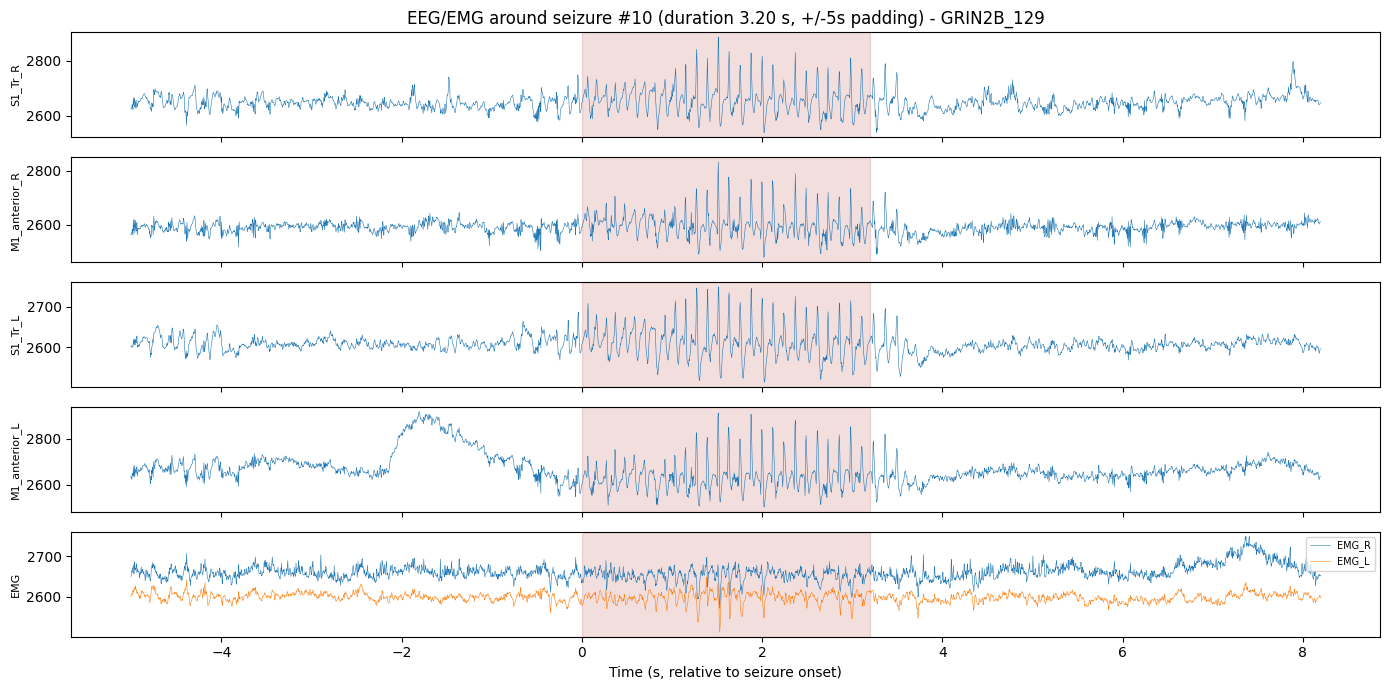

In [55]:
# ── Seizure selection ───────────────────────────────────────────────────────
seizure_idx = 10  # 10th seizure event (0-indexed)
pad_s = 5    # seconds of padding before/after the seizure to include
# ─────────────────────────────────────────────────────────────────────────────

seizure_onset_s = seizure_df["start_time"][seizure_idx]
seizure_offset_s = seizure_df["stop_time"][seizure_idx]

fs = eeg_es.rate

window_start_s = seizure_onset_s - pad_s
window_end_s = seizure_offset_s + pad_s

i_start = int(window_start_s * fs)
i_end = int(window_end_s * fs)
t = np.arange(i_start, i_end) / fs - (seizure_onset_s)  # t=0 at seizure onset

eeg_slice = eeg_es.data[i_start:i_end, :]  # lazy HDF5 read
emg_slice = emg_es.data[i_start:i_end, :]  # lazy HDF5 read

eeg_idx = {"S1_Tr_R": 0, "M1_anterior_R": 3, "S1_Tr_L": 13, "M1_anterior_L": 10}
emg_idx = {"EMG_R": 0, "EMG_L": 1}

fig, axes = plt.subplots(len(eeg_idx) + 1, 1, figsize=(14, 7), sharex=True)

for ax, (label, idx) in zip(axes[:-1], eeg_idx.items()):
    ax.plot(t, eeg_slice[:, idx], lw=0.4)
    ax.set_ylabel(label, fontsize=8)

ax_emg = axes[-1]
for label, idx in emg_idx.items():
    ax_emg.plot(t, emg_slice[:, idx], lw=0.4, label=label)
ax_emg.set_ylabel("EMG", fontsize=8)
ax_emg.legend(fontsize=7, loc="upper right")
ax_emg.set_xlabel("Time (s, relative to seizure onset)")

seizure_duration_s = seizure_offset_s - seizure_onset_s
for ax in axes:
    ax.axvspan(0, seizure_duration_s, color="firebrick", alpha=0.15)

axes[0].set_title(
    f"EEG/EMG around seizure #{seizure_idx} "
    f"(duration {seizure_duration_s:.2f} s, +/-{pad_s}s padding) - GRIN2B_129"
)
plt.tight_layout()
plt.show()

## 9. Per-epoch SWD counts

`swd_epoch_counts` is a `pynwb.epoch.TimeIntervals` table (one row per 5-s
epoch, `swd_count` column) spanning all baseline windows, with a `baseline_window` column
identifying which baseline window each row belongs to.

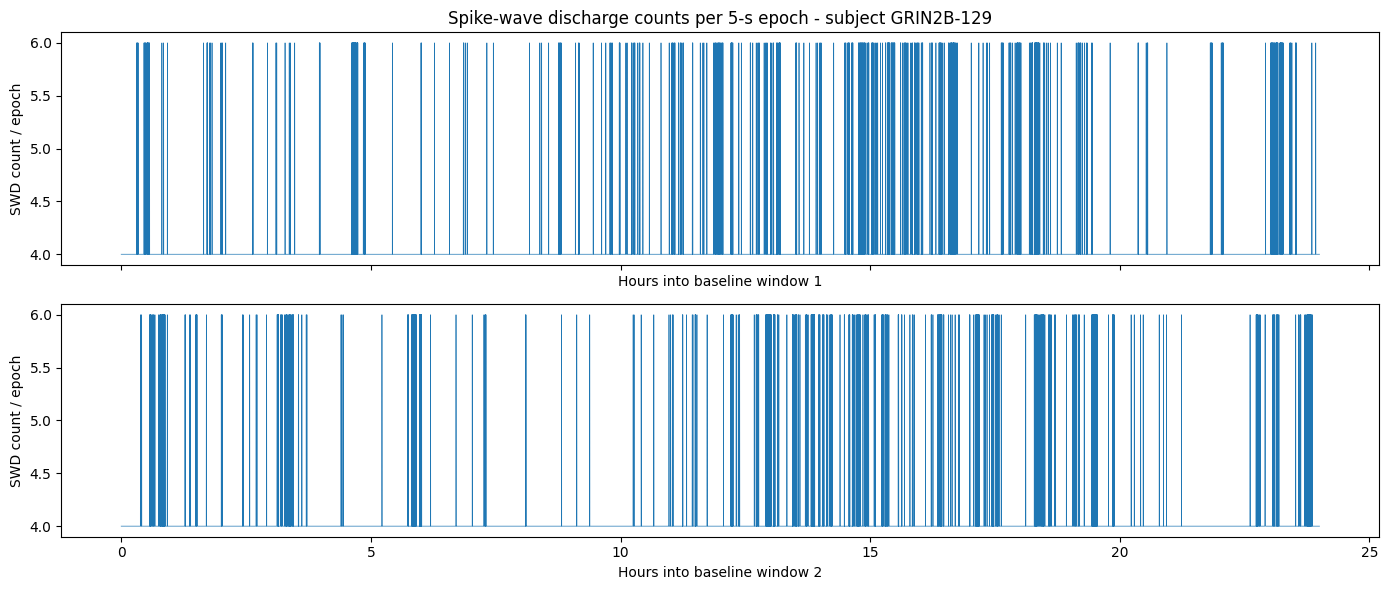

In [22]:
swd_df = behavior["swd_epoch_counts"].to_dataframe()
swd_df_bl1 = swd_df[swd_df["baseline_window"] == "baseline_window_1"]
swd_df_bl2 = swd_df[swd_df["baseline_window"] == "baseline_window_2"]

hours_swd_bl1 = (swd_df_bl1["start_time"] - bl1_start_time) / 3600
hours_swd_bl2 = (swd_df_bl2["start_time"] - bl2_start_time) / 3600

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(hours_swd_bl1, swd_df_bl1["swd_count"], lw=0.5)
axes[0].set_xlabel("Hours into baseline window 1")
axes[0].set_ylabel("SWD count / epoch")
axes[0].set_title(
    f"Spike-wave discharge counts per 5-s epoch - subject {nwb.subject.subject_id}"
)

axes[1].plot(hours_swd_bl2, swd_df_bl2["swd_count"], lw=0.5)
axes[1].set_xlabel("Hours into baseline window 2")
axes[1].set_ylabel("SWD count / epoch")

plt.tight_layout()
plt.show()

In [23]:
# Always close the file when done
#io.close()